In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Размер данных:", df.shape)
print("-" * 40)
df.info()

Размер данных: (7043, 21)
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null  

In [2]:
print(df[df['TotalCharges'] == ' '])

print(df[df['TotalCharges'] == ' ']['tenure'])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [3]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

float64
0


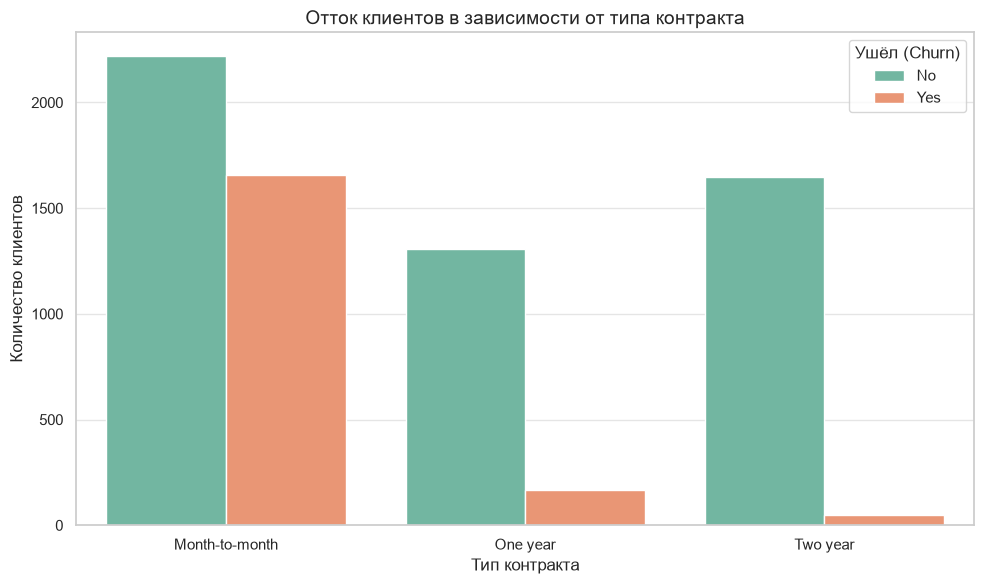

In [7]:
plt.close('all')

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', order=['Month-to-month', 'One year', 'Two year'])

plt.title('Отток клиентов в зависимости от типа контракта', fontsize=14)
plt.xlabel('Тип контракта', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(title='Ушёл (Churn)')

plt.tight_layout()
plt.show()
plt.close()

In [8]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(churn_by_contract.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


Клиенты с помесячным контрактом уходят в 15 раз чаще (42.7%), чем клиенты с двухлетним контрактом (2.8%). Это означает, что:
Тип контракта — одна из самых сильных фичей для модели предсказания оттока.
Бизнес-решение: если мы сможем перевести клиентов с Month-to-month на One year или Two year (например, предложив скидку при годовой оплате), мы сократим отток на 40%.
Приоритет для модели: нам нужно особенно точно предсказывать отток среди клиентов с помесячным контрактом, потому что их большинство и они самые рискованные.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")

Размер X_train: (5634, 19), X_test: (1409, 19)
Доля оттока в train: 26.54%, в test: 26.54%


In [11]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_test)
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

--- Classification Report ---
              precision    recall  f1-score   support

No Churn (0)       0.85      0.90      0.87      1035
   Churn (1)       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- ROC-AUC Score ---
ROC-AUC: 0.8422
--- Confusion Matrix ---


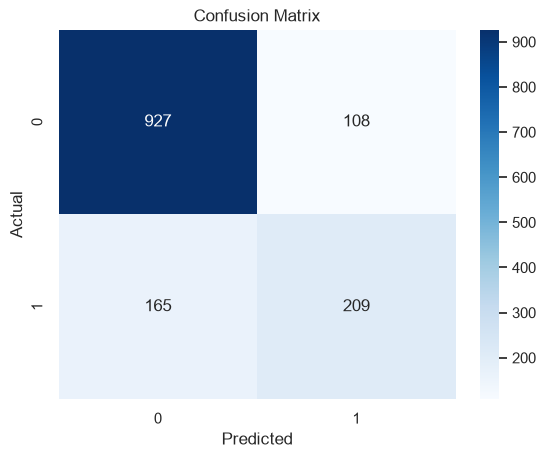

In [12]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)']))

print("--- ROC-AUC Score ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])  # балансировка классов
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn (0)', 'Churn (1)']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

No Churn (0)       0.91      0.72      0.81      1035
   Churn (1)       0.51      0.81      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.74      0.76      1409

ROC-AUC: 0.8430

Confusion Matrix:
[[746 289]
 [ 72 302]]
